In [1]:
import geatpy as ea
import numpy as np
from pyBraytonHeatPump import BraytonHeatPump
import matplotlib.pyplot as plt

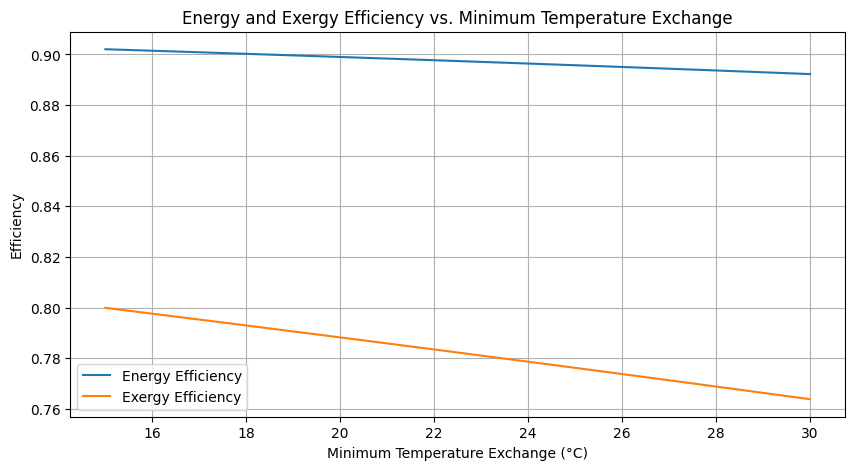

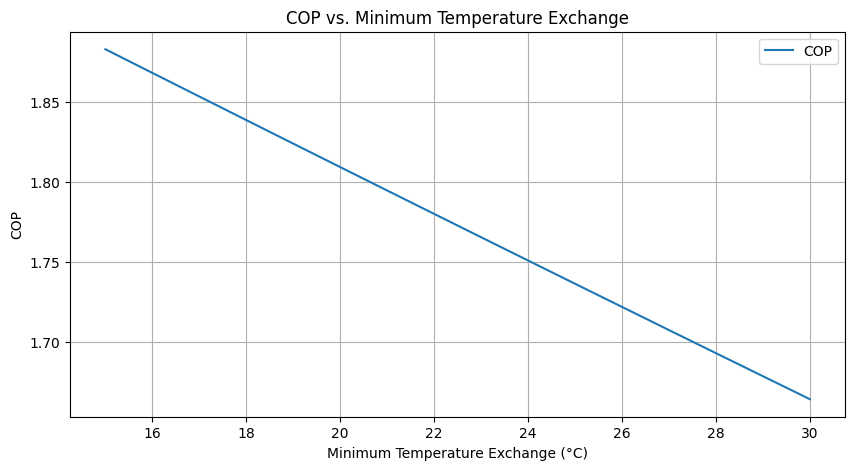

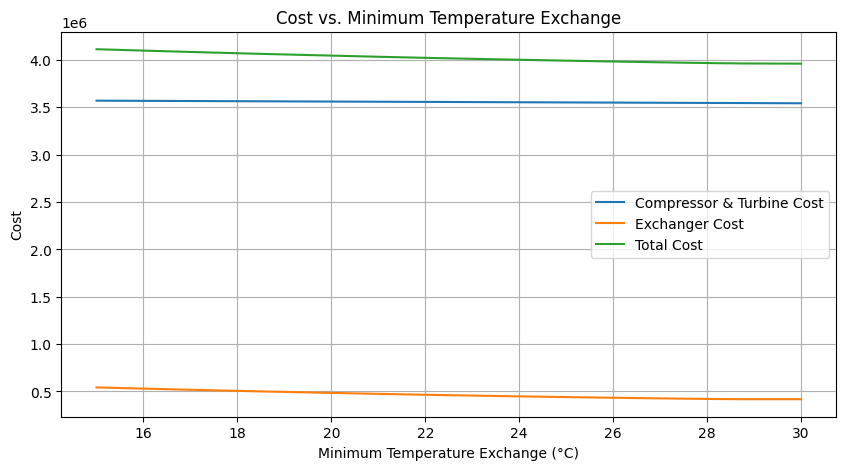

In [2]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(15, 30, 26)  # 生成从15到30（包含）的25个等间距点
for min_temp_exchange in min_temp_exchange_range:
    parameters["min_temperature_exchange"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "energy_eff": results["energy_eff"],
        "exergy_eff": results["exergy_eff"],
        "cop": results["cop"],
        "cost_comp&turb": results["cost"]["cost_comp&turb"],
        "cost_exchanger": results["cost"]["cost_exchanger"],
        "cost_all": results["cost"]["cost_all"]
    })
 
# 提取结果数据
energy_eff = [res["energy_eff"] for res in results_list]
exergy_eff = [res["exergy_eff"] for res in results_list]
cop = [res["cop"] for res in results_list]
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range
 
# 绘制能量效率和㶲效率的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, energy_eff, label='Energy Efficiency')
plt.plot(min_temp_exchange_values, exergy_eff, label='Exergy Efficiency')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('Efficiency')
plt.title('Energy and Exergy Efficiency vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制COP的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cop, label='COP')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('COP')
plt.title('COP vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()

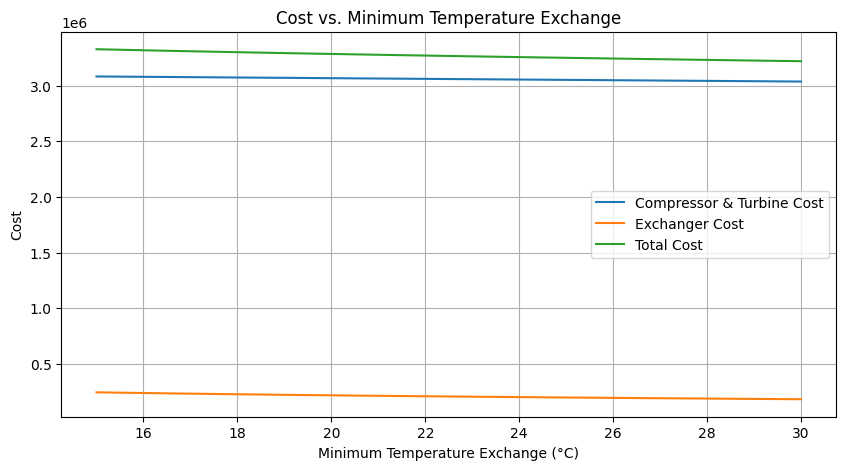

In [3]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(15, 30, 26)  # 生成从15到30（包含）的25个等间距点
for min_temp_exchange in min_temp_exchange_range:
    parameters["min_temperature_exchange"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "cost_comp&turb": results["cost2"]["cost_comp&turb"],
        "cost_exchanger": results["cost2"]["cost_exchanger"],
        "cost_all": results["cost2"]["cost_all"]
    })
 
# 提取结果数据
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range

# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()

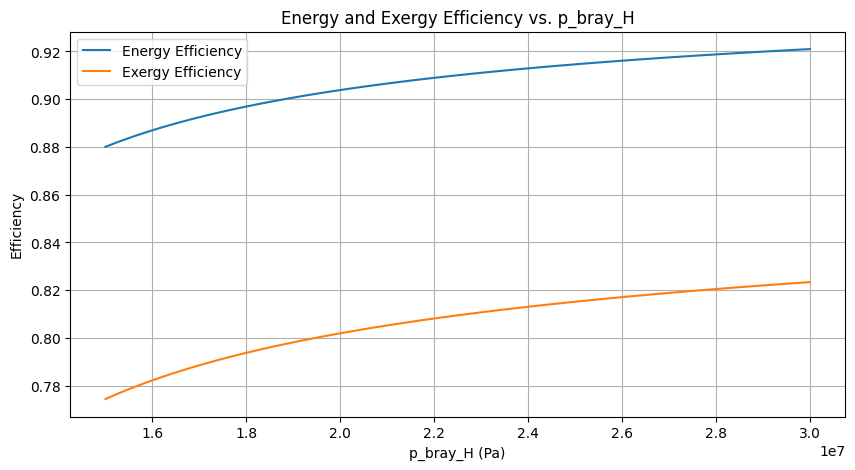

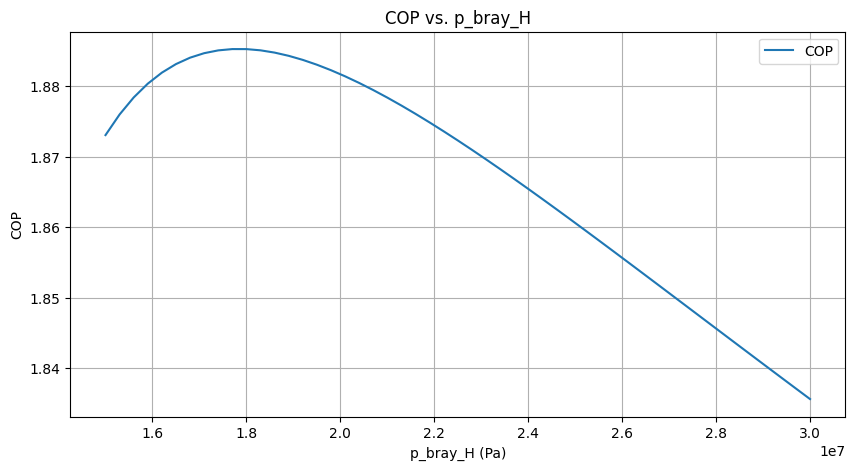

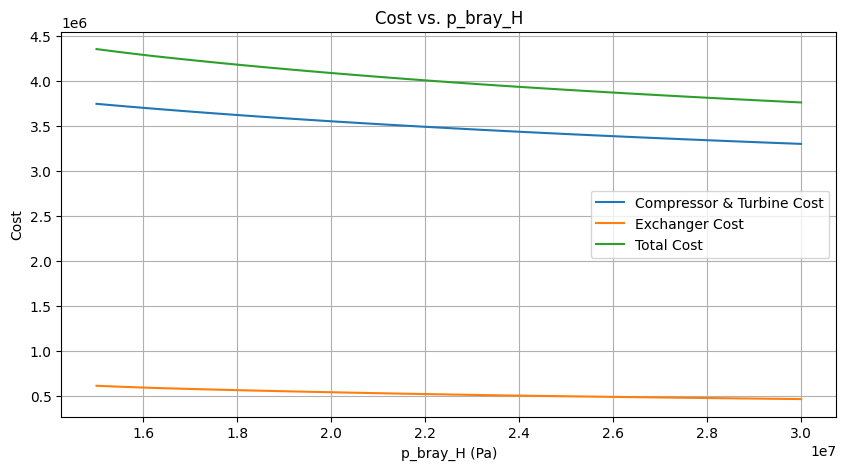

In [3]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的p_bray_H值
p_bray_H_range = np.linspace(15e6, 30e6, 51)  # 生成从15e6到30e6的50个等间距点
for p_bray_H in p_bray_H_range:
    inputs["p_bray_H"] = p_bray_H
    r=(19447839.26865841-7.5e6)/(12827110.4341202-7.5e6)
    inputs["p_bray_M"] = ((p_bray_H-7.5e6)/r)+7.5e6  # 计算中间压力
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "energy_eff": results["energy_eff"],
        "exergy_eff": results["exergy_eff"],
        "cop": results["cop"],
        "cost_comp&turb": results["cost"]["cost_comp&turb"],
        "cost_exchanger": results["cost"]["cost_exchanger"],
        "cost_all": results["cost"]["cost_all"]
    })
 
# 提取结果数据
energy_eff = [res["energy_eff"] for res in results_list]
exergy_eff = [res["exergy_eff"] for res in results_list]
cop = [res["cop"] for res in results_list]
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
p_bray_H_values = p_bray_H_range
 
# 绘制能量效率和㶲效率的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, energy_eff, label='Energy Efficiency')
plt.plot(p_bray_H_values, exergy_eff, label='Exergy Efficiency')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('Efficiency')
plt.title('Energy and Exergy Efficiency vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制COP的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, cop, label='COP')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('COP')
plt.title('COP vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(p_bray_H_values, cost_exchanger, label='Exchanger Cost')
plt.plot(p_bray_H_values, cost_all, label='Total Cost')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('Cost')
plt.title('Cost vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()

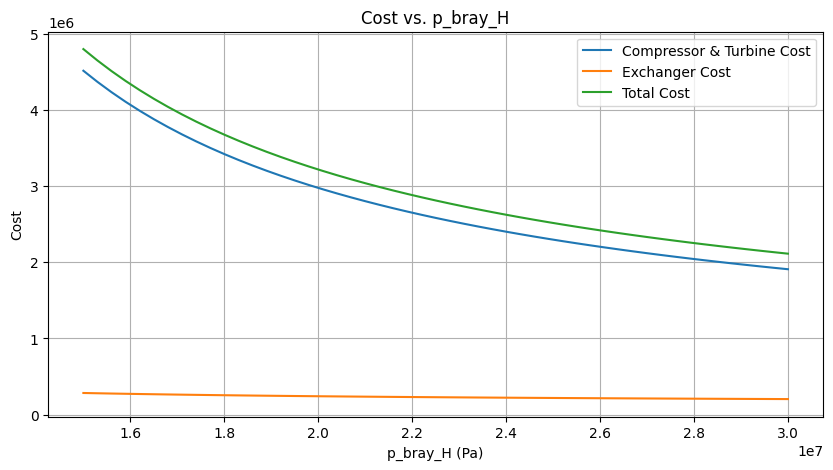

In [4]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的p_bray_H值
p_bray_H_range = np.linspace(15e6, 30e6, 51)  # 生成从15e6到30e6的50个等间距点
for p_bray_H in p_bray_H_range:
    inputs["p_bray_H"] = p_bray_H
    r=(19447839.26865841-7.5e6)/(12827110.4341202-7.5e6)
    inputs["p_bray_M"] = ((p_bray_H-7.5e6)/r)+7.5e6  # 计算中间压力
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({

        "cost_comp&turb": results["cost2"]["cost_comp&turb"],
        "cost_exchanger": results["cost2"]["cost_exchanger"],
        "cost_all": results["cost2"]["cost_all"]
    })
 
# 提取结果数据
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
p_bray_H_values = p_bray_H_range
 

# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(p_bray_H_values, cost_exchanger, label='Exchanger Cost')
plt.plot(p_bray_H_values, cost_all, label='Total Cost')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('Cost')
plt.title('Cost vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()

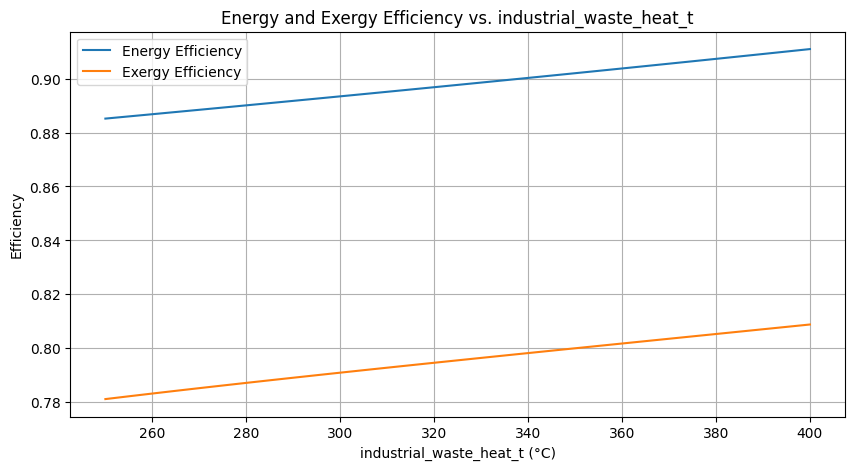

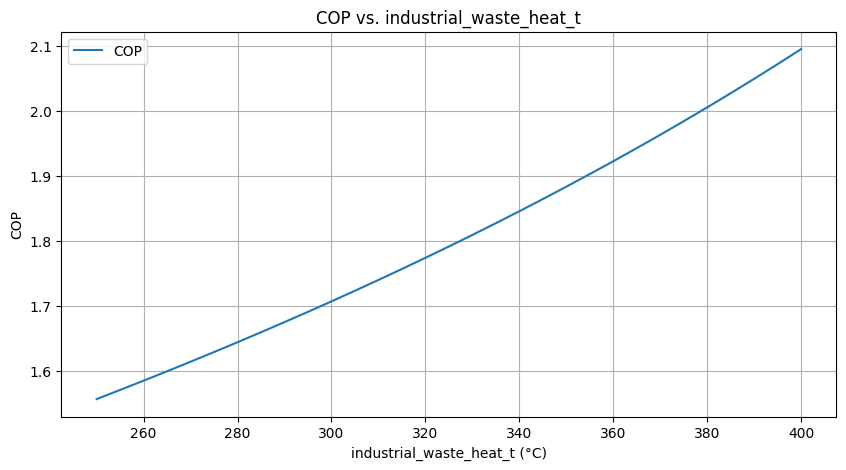

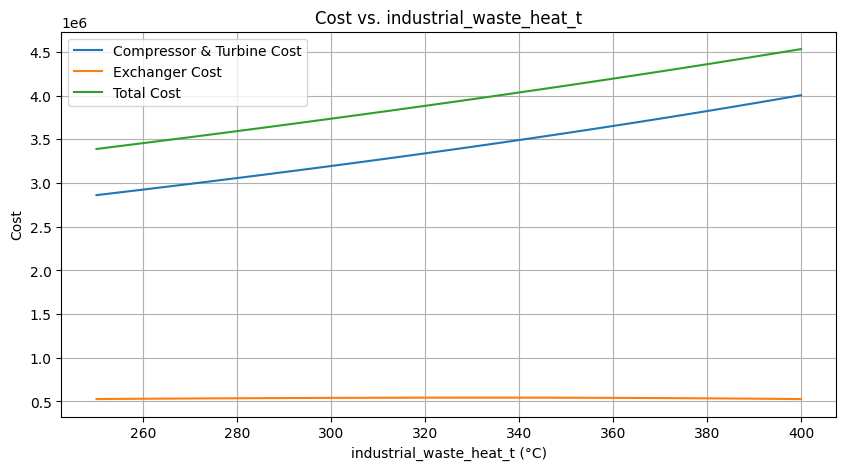

In [4]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(250, 400, 31)  
for min_temp_exchange in min_temp_exchange_range:
    parameters["industrial_waste_heat_t"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "energy_eff": results["energy_eff"],
        "exergy_eff": results["exergy_eff"],
        "cop": results["cop"],
        "cost_comp&turb": results["cost"]["cost_comp&turb"],
        "cost_exchanger": results["cost"]["cost_exchanger"],
        "cost_all": results["cost"]["cost_all"]
    })
 
# 提取结果数据
energy_eff = [res["energy_eff"] for res in results_list]
exergy_eff = [res["exergy_eff"] for res in results_list]
cop = [res["cop"] for res in results_list]
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range
 
# 绘制能量效率和㶲效率的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, energy_eff, label='Energy Efficiency')
plt.plot(min_temp_exchange_values, exergy_eff, label='Exergy Efficiency')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('Efficiency')
plt.title('Energy and Exergy Efficiency vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制COP的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cop, label='COP')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('COP')
plt.title('COP vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()

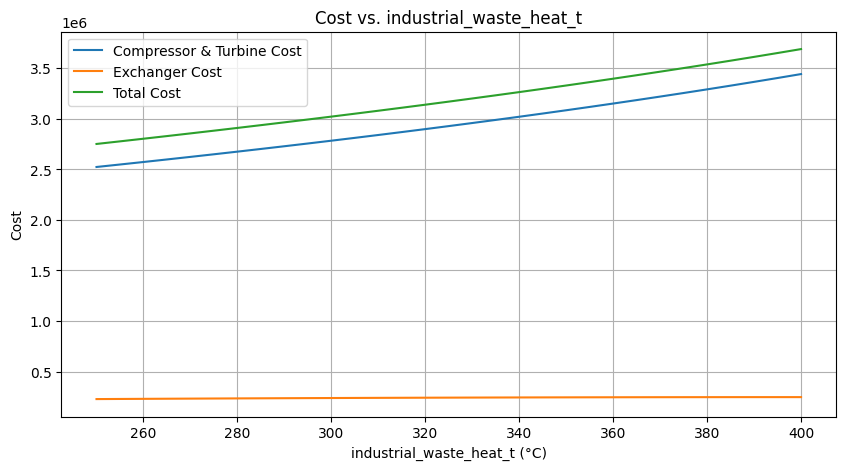

In [5]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(250, 400, 31)  
for min_temp_exchange in min_temp_exchange_range:
    parameters["industrial_waste_heat_t"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({

        "cost_comp&turb": results["cost2"]["cost_comp&turb"],
        "cost_exchanger": results["cost2"]["cost_exchanger"],
        "cost_all": results["cost2"]["cost_all"]
    })
 
# 提取结果数据

cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\837021038.py:117: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\837021038.py:117: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\837021038.py:117: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\837021038.py:117: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\837021038.py:117: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\837021038.py:117: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}

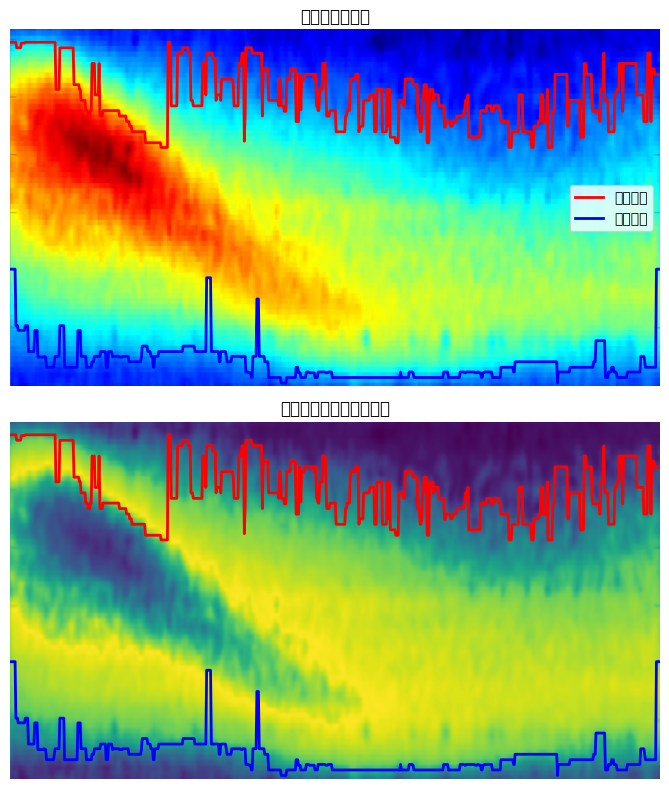

In [10]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# 尝试读取图像
image_path = '边界层.png'

# 检查文件是否存在
if not os.path.exists(image_path):
    raise FileNotFoundError(f"文件 '{image_path}' 不存在")

try:
    # 使用PIL打开图像
    img = Image.open(image_path)
    image = np.array(img)
    
    # 如果图像是RGBA格式，转换为RGB
    if image.shape[2] == 4:
        image = image[..., :3]
        
except Exception as e:
    print(f"读取图像错误: {e}")
    print("请确认文件是有效的图像格式")
    exit()

# 转换为灰度图
if image.ndim == 3:
    gray = np.dot(image[..., :3], [0.2989, 0.5870, 0.1140])
else:
    gray = image.copy()

# 高斯模糊去噪
blurred = gaussian_filter(gray, sigma=1.5)
height, width = blurred.shape

# 存储上下边界层位置
upper_boundary = []
lower_boundary = []

# 参数设置
search_depth = height // 3  # 从壁面向内搜索的深度
grad_threshold_ratio = 0.00005   # 梯度阈值比例
min_grad = 0.0005              # 最小有效梯度 (根据图像调整)

# 处理每一列
for x in range(width):
    col = blurred[:, x]
    
    # 检测上边界层（从顶部向下）
    max_grad = 0
    max_index = 0
    grads = []
    
    # 计算梯度并找到最大梯度位置
    for y in range(1, search_depth):
        grad = abs(col[y] - col[y-1])
        grads.append(grad)
        if grad > max_grad:
            max_grad = grad
            max_index = y
    
    # 确定边界层外边缘
    boundary_y = max_index
    if max_grad > min_grad:
        threshold = max_grad * grad_threshold_ratio
        # 从最大梯度位置向下寻找梯度变小的点
        for y in range(max_index + 1, min(max_index + 50, search_depth)):
            if y-1 < len(grads) and grads[y-1] < threshold:
                boundary_y = y
                break
    upper_boundary.append(boundary_y)
    
    # 检测下边界层（从底部向上）
    max_grad = 0
    max_index = height - 1
    grads = []
    
    # 从底部向上搜索
    for y in range(height - 2, height - search_depth - 1, -1):
        grad = abs(col[y] - col[y+1])
        grads.append(grad)
        if grad > max_grad:
            max_grad = grad
            max_index = y
    
    boundary_y = max_index
    if max_grad > min_grad:
        threshold = max_grad * grad_threshold_ratio
        # 计算当前点在grads中的索引
        idx = height - y - 2
        if idx >= 0 and idx < len(grads) and grads[idx] < threshold:
            boundary_y = y
    lower_boundary.append(boundary_y)

# 绘制结果
plt.figure(figsize=(12, 8))

# 显示原始图像
plt.subplot(2, 1, 1)
plt.imshow(image)
plt.plot(upper_boundary, 'r-', linewidth=2, label='上边界层')
plt.plot(lower_boundary, 'b-', linewidth=2, label='下边界层')
plt.legend()
plt.title('边界层检测结果')
plt.axis('off')

# 显示灰度图像和边界层位置
plt.subplot(2, 1, 2)
plt.imshow(blurred, cmap='viridis')
plt.plot(upper_boundary, 'r-', linewidth=2)
plt.plot(lower_boundary, 'b-', linewidth=2)
plt.title('灰度图像上的边界层位置')
plt.axis('off')

plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\3569366242.py:146: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\3569366242.py:146: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\3569366242.py:146: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\3569366242.py:146: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\3569366242.py:146: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10200\3569366242.py:146: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH

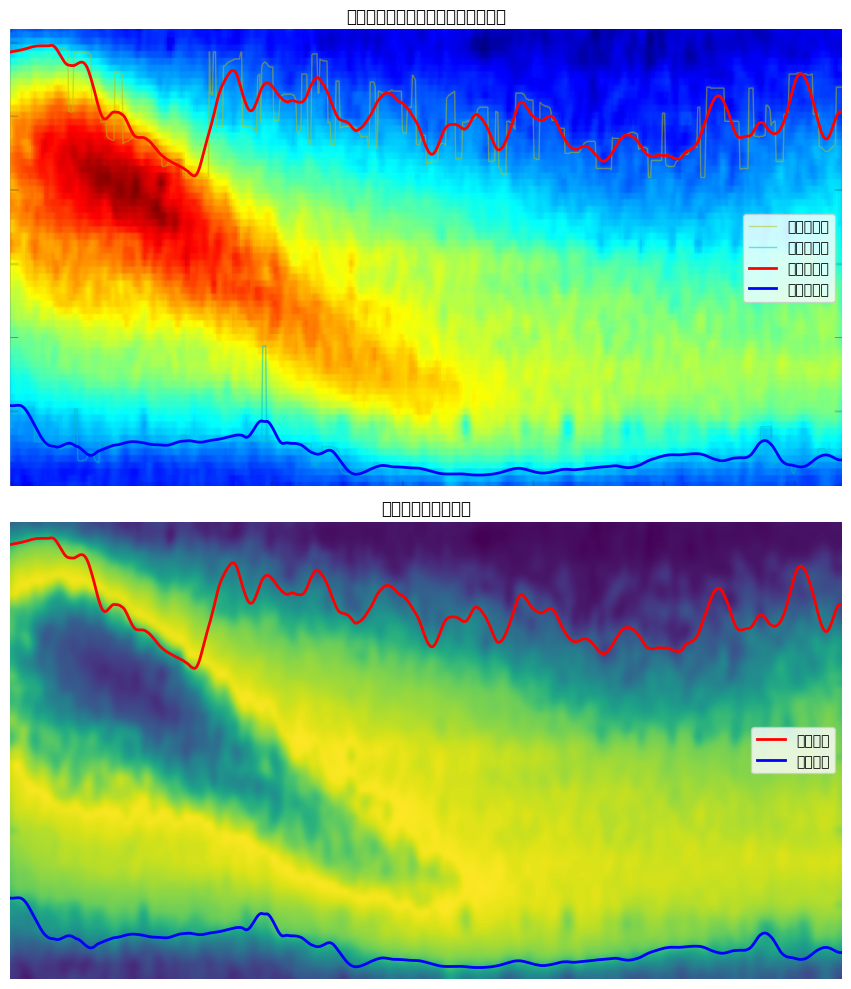

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter1d
from scipy.signal import savgol_filter

# 尝试读取图像
image_path = '边界层.png'

# 检查文件是否存在
if not os.path.exists(image_path):
    raise FileNotFoundError(f"文件 '{image_path}' 不存在")

try:
    # 使用PIL打开图像
    img = Image.open(image_path)
    image = np.array(img)
    
    # 如果图像是RGBA格式，转换为RGB
    if image.ndim == 3 and image.shape[2] == 4:
        image = image[..., :3]
        
except Exception as e:
    print(f"读取图像错误: {e}")
    print("请确认文件是有效的图像格式")
    exit()

# 转换为灰度图
if image.ndim == 3:
    gray = np.dot(image[..., :3], [0.2989, 0.5870, 0.1140])
else:
    gray = image.copy()

# 增强高斯模糊去噪
blurred = gaussian_filter(gray, sigma=3.0)  # 增加sigma值使图像更平滑
height, width = blurred.shape

# 存储上下边界层位置
upper_boundary = []
lower_boundary = []

# 参数设置
search_depth = height // 3  # 从壁面向内搜索的深度
grad_threshold_ratio = 0.9   # 梯度阈值比例，手动调整
min_grad = 0.05              # 最小有效梯度，手动调整
window_size = 5              # 梯度计算窗口大小

# 处理每一列
for x in range(width):
    col = blurred[:, x]
    
    # 检测上边界层（从顶部向下）
    max_grad = 0
    max_index = 0
    
    # 使用窗口计算梯度 - 更稳定
    for y in range(1, search_depth - window_size):
        # 计算窗口内的平均梯度
        grad_window = [abs(col[y+i] - col[y+i-1]) for i in range(window_size)]
        avg_grad = np.mean(grad_window)
        
        if avg_grad > max_grad:
            max_grad = avg_grad
            max_index = y + window_size // 2  # 取窗口中心位置
    
    # 确定边界层外边缘
    boundary_y = max_index
    if max_grad > min_grad:
        threshold = max_grad * grad_threshold_ratio
        # 从最大梯度位置向下寻找梯度变小的点
        for y in range(max_index + 1, min(max_index + 50, search_depth)):
            # 同样使用窗口计算梯度
            if y + window_size < search_depth:
                grad_window = [abs(col[y+i] - col[y+i-1]) for i in range(window_size)]
                avg_grad = np.mean(grad_window)
                
                if avg_grad < threshold:
                    boundary_y = y
                    break
    
    upper_boundary.append(boundary_y)
    
    # 检测下边界层（从底部向上）
    max_grad = 0
    max_index = height - 1
    
    # 从底部向上搜索
    for y in range(height - 2, height - search_depth - window_size, -1):
        grad_window = [abs(col[y-i] - col[y-i+1]) for i in range(window_size)]
        avg_grad = np.mean(grad_window)
        
        if avg_grad > max_grad:
            max_grad = avg_grad
            max_index = y - window_size // 2
    
    boundary_y = max_index
    if max_grad > min_grad:
        threshold = max_grad * grad_threshold_ratio
        for y in range(max_index - 1, max(max_index - 50, height - search_depth - 1), -1):
            if y - window_size > height - search_depth:
                grad_window = [abs(col[y-i] - col[y-i+1]) for i in range(window_size)]
                avg_grad = np.mean(grad_window)
                
                if avg_grad < threshold:
                    boundary_y = y
                    break
    
    lower_boundary.append(boundary_y)

# 对边界层位置进行平滑处理
def smooth_boundary(boundary, window_size=15, poly_order=3):
    """使用Savitzky-Golay滤波器平滑边界"""
    # 先使用移动平均
    smoothed = uniform_filter1d(np.array(boundary), size=window_size)
    # 再使用Savitzky-Golay滤波器
    return savgol_filter(smoothed, window_length=2*(window_size//2)+1, polyorder=poly_order)

# 应用平滑滤波
smooth_upper = smooth_boundary(upper_boundary, window_size=21)
smooth_lower = smooth_boundary(lower_boundary, window_size=21)

# 绘制结果
plt.figure(figsize=(12, 10))

# 原始图像上的原始和平滑边界
plt.subplot(2, 1, 1)
plt.imshow(image)
plt.plot(upper_boundary, 'y-', linewidth=1, alpha=0.5, label='原始上边界')
plt.plot(lower_boundary, 'c-', linewidth=1, alpha=0.5, label='原始下边界')
plt.plot(smooth_upper, 'r-', linewidth=2, label='平滑上边界')
plt.plot(smooth_lower, 'b-', linewidth=2, label='平滑下边界')
plt.legend()
plt.title('边界层检测结果（原始与平滑对比）')
plt.axis('off')

# 灰度图像上的边界层位置
plt.subplot(2, 1, 2)
plt.imshow(blurred, cmap='viridis')
plt.plot(smooth_upper, 'r-', linewidth=2, label='上边界层')
plt.plot(smooth_lower, 'b-', linewidth=2, label='下边界层')
plt.legend()
plt.title('平滑后的边界层位置')
plt.axis('off')

plt.tight_layout()
plt.show()